In [1]:
# %load_ext autoreload
# %autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import skopi as sk

import torch
from tqdm import tqdm 
import time
import h5py

from neurorient import uniform_points_on_sphere
from neurorient.reconstruction.slicing import get_reciprocal_mesh, get_real_mesh
import scipy

import os, glob
os.environ["USE_CUPY"] = "1"
os.environ.get('USE_CUPY')

/pscratch/sd/z/zhantao/conda/om/lib/python3.9/site-packages/skopi/diffraction.py:76: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def get_phase(atom_pos, q_xyz):
/pscratch/sd/z/zhantao/conda/om/lib/python3.9/site-packages/skopi/diffraction.py:90: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def cal(f_hkl, atom_pos, q_xyz, xyz_ind, pixel_number):
/pscratch/sd/z

'1'

In [2]:
data_type = 'downsampled_128x128'

img_size = 128

In [3]:
data_path = "/pscratch/sd/z/zhantao/neurorient_repo/data_PR772"
save_dir = '/pscratch/sd/z/zhantao/neurorient_repo/data/PR772'

In [4]:
h5_file_list = sorted(glob.glob(os.path.join(data_path, "*.h5")))
print(*h5_file_list, sep='\n')

/pscratch/sd/z/zhantao/neurorient_repo/data_PR772/amo86615_182_PR772_single.h5
/pscratch/sd/z/zhantao/neurorient_repo/data_PR772/amo86615_183_PR772_single.h5
/pscratch/sd/z/zhantao/neurorient_repo/data_PR772/amo86615_184_PR772_single.h5
/pscratch/sd/z/zhantao/neurorient_repo/data_PR772/amo86615_185_PR772_single.h5
/pscratch/sd/z/zhantao/neurorient_repo/data_PR772/amo86615_186_PR772_single.h5
/pscratch/sd/z/zhantao/neurorient_repo/data_PR772/amo86615_188_PR772_single.h5
/pscratch/sd/z/zhantao/neurorient_repo/data_PR772/amo86615_190_PR772_single.h5
/pscratch/sd/z/zhantao/neurorient_repo/data_PR772/amo86615_191_PR772_single.h5
/pscratch/sd/z/zhantao/neurorient_repo/data_PR772/amo86615_192_PR772_single.h5
/pscratch/sd/z/zhantao/neurorient_repo/data_PR772/amo86615_193_PR772_single.h5
/pscratch/sd/z/zhantao/neurorient_repo/data_PR772/amo86615_194_PR772_single.h5
/pscratch/sd/z/zhantao/neurorient_repo/data_PR772/amo86615_196_PR772_single.h5
/pscratch/sd/z/zhantao/neurorient_repo/data_PR772/am

In [5]:
photons = []

for _h5_file in tqdm(h5_file_list):
    with h5py.File(_h5_file, "r") as f:
        _photons = f['photonConverter/pnccdBack/photonCount'][:]
        photons.append(_photons)
        
images = np.concatenate(photons, axis=0)[:,1:-2,:]

  0%|          | 0/13 [00:00<?, ?it/s]

100%|██████████| 13/13 [00:07<00:00,  1.67it/s]


In [6]:
print(images.shape)

(14772, 257, 257)


In [7]:
det = np.loadtxt('input/dragonfly/det_pnccd_back.dat', skiprows=1)
det_shape = (260, 257)

In [8]:
pixel_position_reciprocal = 1e7 * det[:,:3].reshape((1,)+det_shape+(3,))
pixel_position_reciprocal = pixel_position_reciprocal[:,1:-2,:,:]

In [9]:
img_real_mesh = get_real_mesh(min(det_shape), pixel_position_reciprocal.max())
_mesh = get_reciprocal_mesh(min(det_shape), pixel_position_reciprocal.max())
vol_real_mesh = get_real_mesh(_mesh.shape[0], _mesh.max())

In [52]:
idx_xx, idx_yy = np.meshgrid(np.arange(img_size), np.arange(img_size))

In [53]:
pixel_index_map = np.concatenate([idx_xx[None,...,None], idx_yy[None,...,None]], axis=-1)

In [44]:
zoom_ratio = img_size / min(det_shape)

images_downsampled = np.zeros((images.shape[0], img_size, img_size))

In [45]:
for i in tqdm(range(images.shape[0])):
    img = images[i]
    img_downsampled = scipy.ndimage.zoom(img, zoom_ratio, order=1)
    images_downsampled[i] = img_downsampled

100%|██████████| 14772/14772 [00:07<00:00, 1891.42it/s]


In [55]:
pixel_position_reciprocal_downsampled = scipy.ndimage.zoom(pixel_position_reciprocal, (1, zoom_ratio, zoom_ratio, 1), order=1)

img_real_mesh_downsampled = get_real_mesh(img_size, pixel_position_reciprocal_downsampled.max())
_mesh_downsampled = get_reciprocal_mesh(img_size, pixel_position_reciprocal_downsampled.max())
vol_real_mesh_downsampled = get_real_mesh(_mesh_downsampled.shape[0], _mesh_downsampled.max())

In [57]:
pt_fpath = os.path.join(save_dir, f'PR772_neurorient_{data_type}.pt')
torch.save(
    {
        'orientations': None,
        'intensities': torch.from_numpy(images_downsampled.astype('float')).float(),
        'pixel_position_reciprocal': torch.from_numpy(pixel_position_reciprocal_downsampled).float(),
        'pixel_index_map': torch.from_numpy(pixel_index_map).long(),
        'volume': None,
        'img_real_mesh': img_real_mesh_downsampled.float(),
        'vol_real_mesh': vol_real_mesh_downsampled.float(),
        'time_stamp': time.strftime("%Y%m%d-%H%M")
    }, pt_fpath
)
print("data wrote to: \n", pt_fpath)

data wrote to: 
 /pscratch/sd/z/zhantao/neurorient_repo/data/PR772/PR772_neurorient_downsampled_128x128.pt


In [58]:
pixel_distance_reciprocal = np.linalg.norm(pixel_position_reciprocal_downsampled, axis=-1)

In [59]:
h5_fpath = os.path.join(
    save_dir, 
    f'PR772_neurorient_{data_type}.h5')
with h5py.File(h5_fpath, 'w') as f:
    f.create_dataset('intensities', data=images_downsampled[:, None])
    f.create_dataset('orientations', data=np.zeros((images_downsampled.shape[0], 4)))
    f.create_dataset('pixel_position_reciprocal', data=pixel_position_reciprocal_downsampled)
    f.create_dataset('pixel_distance_reciprocal', data=pixel_distance_reciprocal)
    f.create_dataset('pixel_index_map', data=pixel_index_map)
print("data wrote to: \n", h5_fpath)

data wrote to: 
 /pscratch/sd/z/zhantao/neurorient_repo/data/PR772/PR772_neurorient_downsampled_128x128.h5


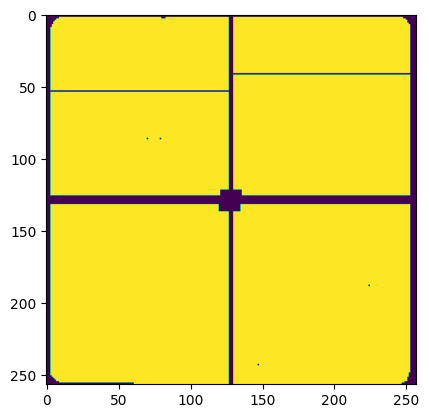

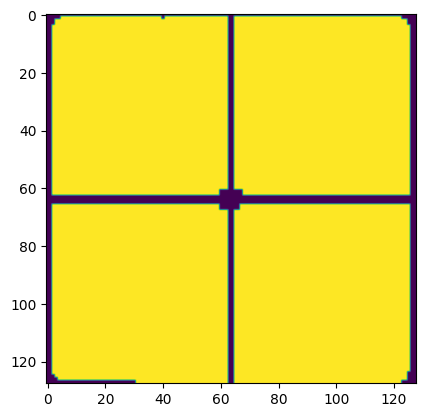

In [68]:
_beam_stop_mask = det[:,-1].reshape(det_shape)[1:-2,:]
beam_stop_mask = torch.zeros(_beam_stop_mask.shape)
beam_stop_mask[_beam_stop_mask!=2] = 1
plt.imshow(beam_stop_mask)

beam_stop_mask_downsampled = scipy.ndimage.zoom(beam_stop_mask, zoom_ratio, order=1)
beam_stop_mask_downsampled[beam_stop_mask_downsampled>=0.5] = 1
beam_stop_mask_downsampled[beam_stop_mask_downsampled<0.5] = 0
plt.figure()
plt.imshow(beam_stop_mask_downsampled)
torch.save({'mask': torch.from_numpy(beam_stop_mask_downsampled).float()}, f'input/PR772/beam_stop_mask_{data_type}.pt')